In [13]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import os

# 경로 설정
BASE_DIR = "/workspace/final_exam"
IMG_PATH = os.path.join(BASE_DIR, "visualization")
REPORT_PATH = os.path.join(BASE_DIR, "Report.txt")

def show_result(exp_name, option_desc):
    # 1. Report.txt에서 결과 한 줄 읽어오기
    found_text = ""
    with open(REPORT_PATH, "r", encoding="utf-8") as f:
        for line in f:
            if f"[{exp_name}]" in line:
                found_text = line.strip()
                break

    # 2. 텍스트 결과 출력
    print(f"[{exp_name}] 학습 옵션 : {option_desc}")
    print(found_text)
    print("-" * 60)

    # 3. 그래프 이미지 좌우 배치 출력
    acc_path = os.path.join(IMG_PATH, f"{exp_name}_acc.png")
    loss_path = os.path.join(IMG_PATH, f"{exp_name}_loss.png")
    
    img_acc = mpimg.imread(acc_path)
    img_loss = mpimg.imread(loss_path)
    
    # 1행 2열로 그래프 그리기
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    
    axes[0].imshow(img_acc)
    axes[0].axis('off')
    
    axes[1].imshow(img_loss)
    axes[1].axis('off')
    
    plt.show()

[01_Baseline] 학습 옵션 : 증강 없음, 규제 없음
[01_Baseline] Test Acc: 0.9987 / Loss: 0.0529 (Aug:False, Drop:False, L2:False)
------------------------------------------------------------


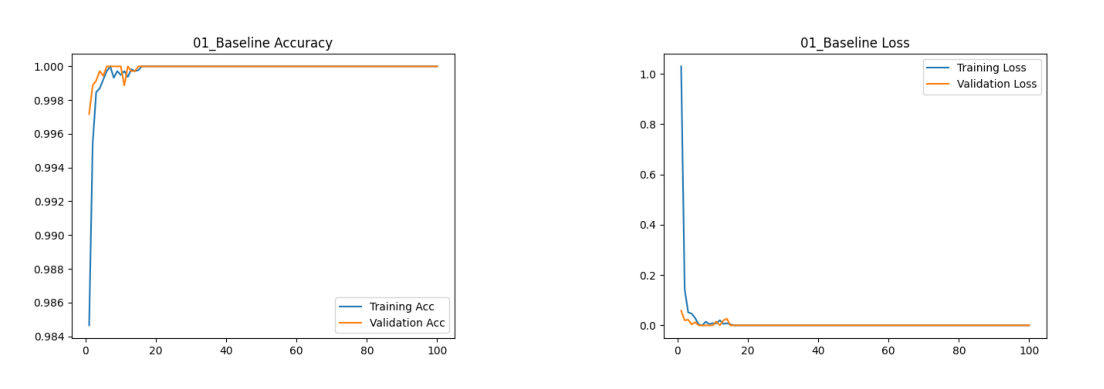

In [14]:
# 1. Baseline
show_result("01_Baseline", "증강 없음, 규제 없음")

[01_Baseline]
정확도 그래프를 보면, 시작하자마나 정확도가 매우 높고, 손실역시 시작과 동시에 0에 가까운 모습이 확인된다. 그 뒤로 1자로 쭉 이어지는 안정적인 모습이 확인됨....
증강도 없고 규제도 없어서 과적합을 예상했으나, 생각보다 너무 잘나옴..... 

[02_AugOnly] 학습 옵션 : 증강 있음(RandomRotation 0.1, Zoom 0.1, Translation 0.1), 규제 없음
[02_AugOnly] Test Acc: 0.9977 / Loss: 0.0643 (Aug:True, Drop:False, L2:False)
------------------------------------------------------------


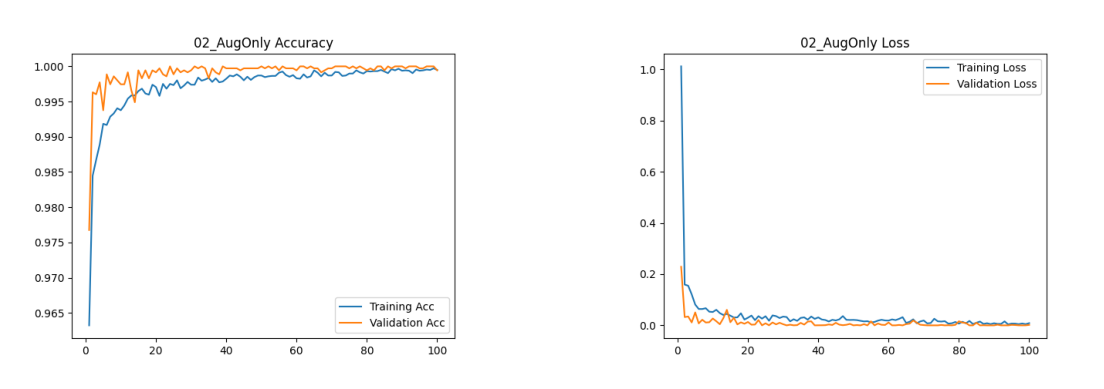

In [15]:
# 2. AugOnly
show_result("02_AugOnly", "증강 있음(RandomRotation 0.1, Zoom 0.1, Translation 0.1), 규제 없음")

[02_AugOnly]
보통은 학습 정확도가 더 높기 마련인데 얘는 검증정확도가 더 높은것이 확인됨 손실 그래프도 검증손실이 더 낮은 경향을 보임
학습 데이터에 증강이 적용되었기 때문에 학습을 더 어려워한걸까 BaseLine 보면 그런것 같기도 하고

[03_Reg_Drop] 학습 옵션 : 증강 없음, 규제 있음(Dropout 0.5)
[03_Reg_Drop] Test Acc: 0.9990 / Loss: 0.0053 (Aug:False, Drop:True, L2:False)
------------------------------------------------------------


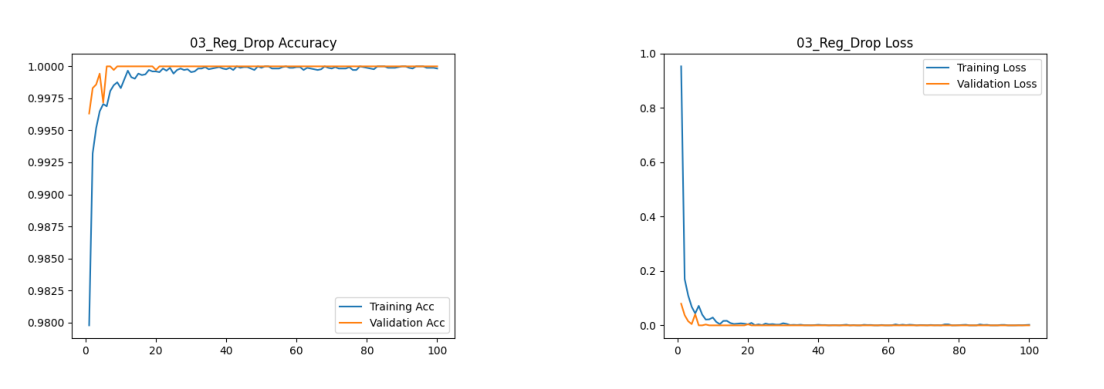

In [16]:
# 3. Reg_Drop
show_result("03_Reg_Drop", "증강 없음, 규제 있음(Dropout 0.5)")

[03_Reg_Drop]
정확도도 가장 높고 손실도 가장 낮은 모델임
드롭아웃 규제가 적용되서 Baseline처럼 수직 상승하긴 조금 더 천천히 도달함. 검증 데이터는 안정적으로 1에 가까이 수렴되어보임
손실 그래프도 굉장히 낮음 분류를 가장 잘 하고있다는것.

[04_Reg_L2] 학습 옵션 : 증강 없음, 규제 있음(L2 0.001)
[04_Reg_L2] Test Acc: 0.9987 / Loss: 0.0085 (Aug:False, Drop:False, L2:True)
------------------------------------------------------------


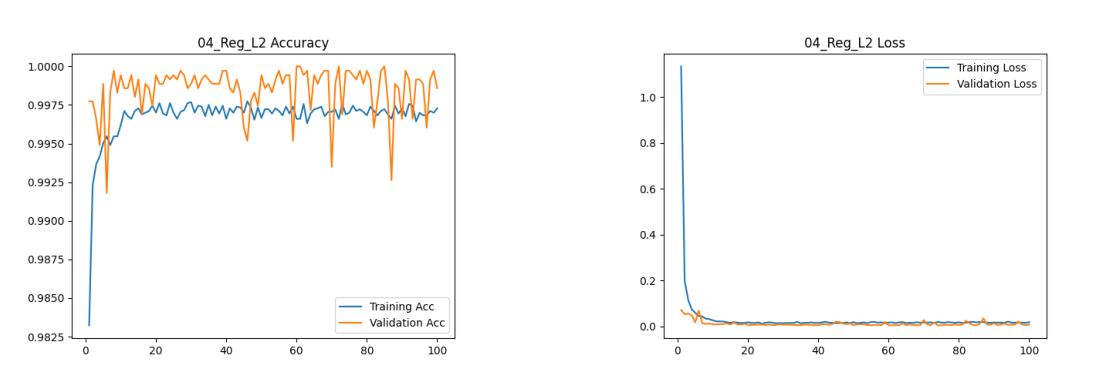

In [17]:
# 4. Reg_L2
show_result("04_Reg_L2", "증강 없음, 규제 있음(L2 0.001)")

[04_Reg_L2]
결과값은 다 잘 나오는데 이게 뭔가 싶음.
검증 정확도가 미친듯이 요동침
매 에폭마다 

[05_Reg_DropL2] 학습 옵션 : 증강 없음, 규제 있음(Dropout 0.5, L2 0.001)
[05_Reg_DropL2] Test Acc: 0.9977 / Loss: 0.0165 (Aug:False, Drop:True, L2:True)
------------------------------------------------------------


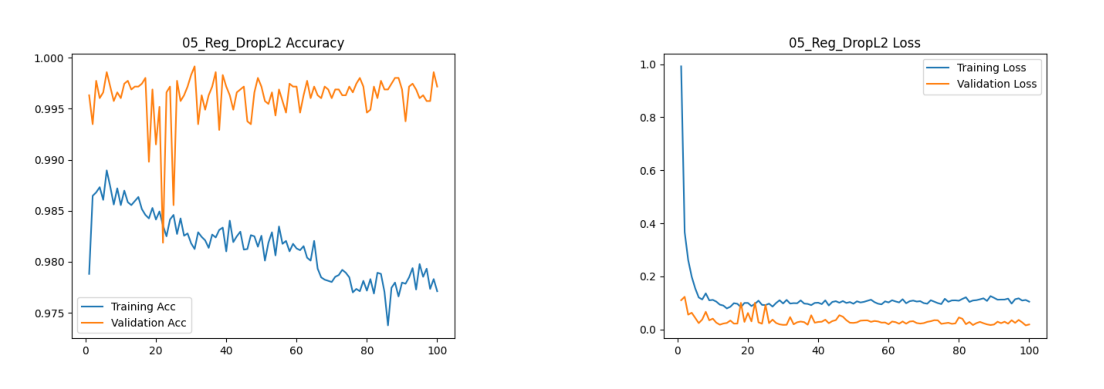

In [18]:
# 5. Reg_DropL2
show_result("05_Reg_DropL2", "증강 없음, 규제 있음(Dropout 0.5, L2 0.001)")

[06_Total_Drop] 학습 옵션 : 증강 있음(RandomRotation 0.1, Zoom 0.1, Translation 0.1), 규제 있음(Dropout 0.5)
[06_Total_Drop] Test Acc: 0.9990 / Loss: 0.0326 (Aug:True, Drop:True, L2:False)
------------------------------------------------------------


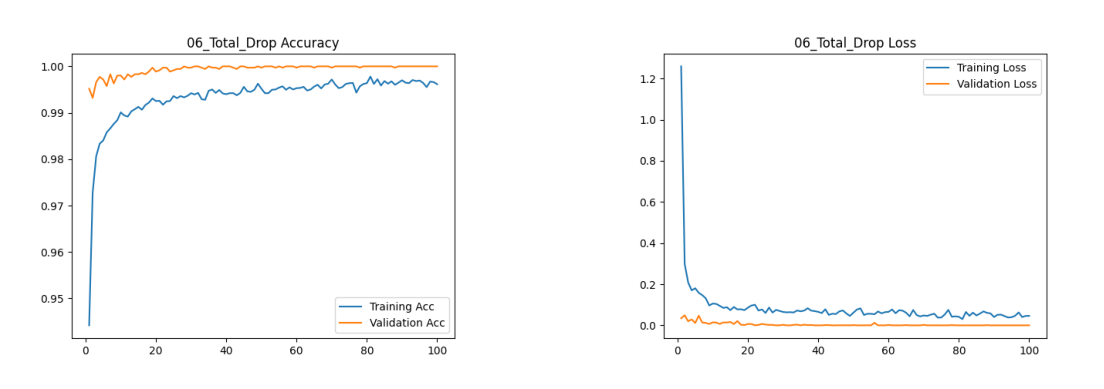

In [19]:
# 6. Total_Drop
show_result("06_Total_Drop", "증강 있음(RandomRotation 0.1, Zoom 0.1, Translation 0.1), 규제 있음(Dropout 0.5)")

[07_Total_L2] 학습 옵션 : 증강 있음(RandomRotation 0.1, Zoom 0.1, Translation 0.1), 규제 있음(L2 0.001)
[07_Total_L2] Test Acc: 0.9980 / Loss: 0.0239 (Aug:True, Drop:False, L2:True)
------------------------------------------------------------


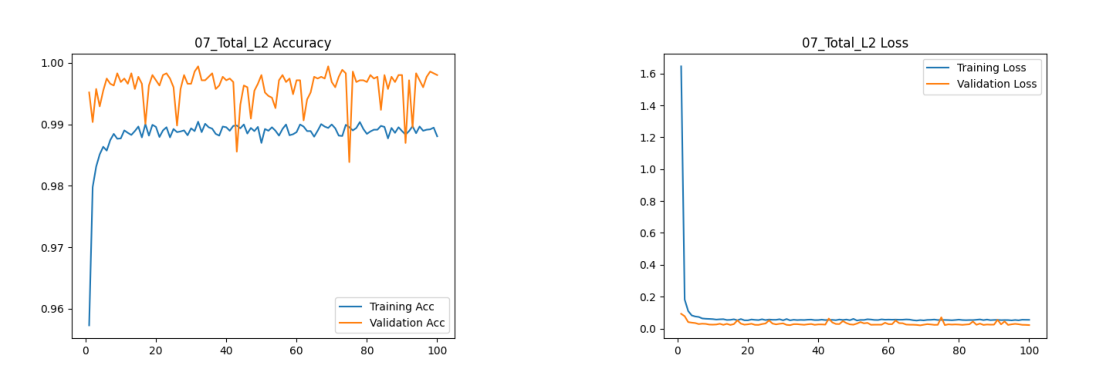

In [20]:
# 7. Total_L2
show_result("07_Total_L2", "증강 있음(RandomRotation 0.1, Zoom 0.1, Translation 0.1), 규제 있음(L2 0.001)")

[08_Total_ALL] 학습 옵션 : 증강 있음(RandomRotation 0.1, Zoom 0.1, Translation 0.1), 규제 있음(Dropout 0.5, L2 0.001)
[08_Total_ALL] Test Acc: 0.9956 / Loss: 0.0525 (Aug:True, Drop:True, L2:True)
------------------------------------------------------------


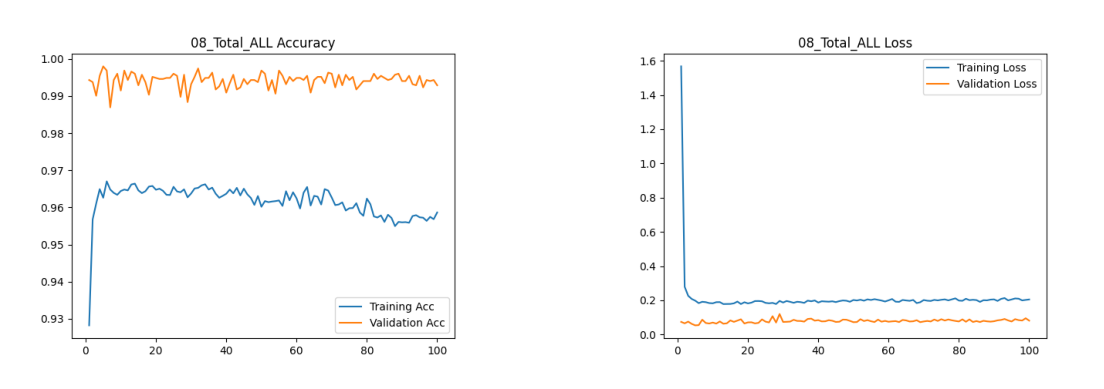

In [21]:
# 8. Total_ALL
show_result("08_Total_ALL", "증강 있음(RandomRotation 0.1, Zoom 0.1, Translation 0.1), 규제 있음(Dropout 0.5, L2 0.001)")